# Creating Word Vectors with word2vec

In this notebook, we create word vectors from a corpus of public-domain books, a selection from [Project Gutenberg](https://www.gutenberg.org/).

#### Load dependencies

In [2]:
import nltk
from nltk import word_tokenize, sent_tokenize
import gensim
from gensim.models.word2vec import Word2Vec
from sklearn.manifold import TSNE
import pandas as pd
from bokeh.io import output_notebook
from bokeh.plotting import show, figure
%matplotlib inline

In [3]:
nltk.download('punkt') # English-language sentence tokenizer (not all periods end sentences; not all sentences start with a capital letter)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/garvitkhurana/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

#### Load data

In [5]:
nltk.download('gutenberg')

[nltk_data] Downloading package gutenberg to
[nltk_data]     /Users/garvitkhurana/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


True

In [6]:
from nltk.corpus import gutenberg

In [7]:
len(gutenberg.fileids())

18

In [15]:
gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

#### Tokenize text

In [9]:
gberg_sent_tokens = sent_tokenize(gutenberg.raw())

In [39]:
gberg_sent_tokens[10:20]

['It was on the wedding-day\nof this beloved friend that Emma first sat in mournful thought\nof any continuance.',
 'The wedding over, and the bride-people gone,\nher father and herself were left to dine together, with no prospect\nof a third to cheer a long evening.',
 'Her father composed himself\nto sleep after dinner, as usual, and she had then only to sit\nand think of what she had lost.',
 'The event had every promise of happiness for her friend.',
 "Mr. Weston\nwas a man of unexceptionable character, easy fortune, suitable age,\nand pleasant manners; and there was some satisfaction in considering\nwith what self-denying, generous friendship she had always wished\nand promoted the match; but it was a black morning's work for her.",
 'The want of Miss Taylor would be felt every hour of every day.',
 'She recalled her past kindness--the kindness, the affection of sixteen\nyears--how she had taught and how she had played with her from five\nyears old--how she had devoted all her pow

In [40]:
gberg_sent_tokens[1]

"She was the youngest of the two daughters of a most affectionate,\nindulgent father; and had, in consequence of her sister's marriage,\nbeen mistress of his house from a very early period."

In [41]:
word_tokenize(gberg_sent_tokens[1])

['She',
 'was',
 'the',
 'youngest',
 'of',
 'the',
 'two',
 'daughters',
 'of',
 'a',
 'most',
 'affectionate',
 ',',
 'indulgent',
 'father',
 ';',
 'and',
 'had',
 ',',
 'in',
 'consequence',
 'of',
 'her',
 'sister',
 "'s",
 'marriage',
 ',',
 'been',
 'mistress',
 'of',
 'his',
 'house',
 'from',
 'a',
 'very',
 'early',
 'period',
 '.']

In [60]:
word_tokenize(gberg_sent_tokens[1])[14]

'father'

In [43]:
# a convenient method that handles newlines, as well as tokenizing sentences and words in one shot
gberg_sents = gutenberg.sents()

In [51]:
gberg_sents[3]

['Emma',
 'Woodhouse',
 ',',
 'handsome',
 ',',
 'clever',
 ',',
 'and',
 'rich',
 ',',
 'with',
 'a',
 'comfortable',
 'home',
 'and',
 'happy',
 'disposition',
 ',',
 'seemed',
 'to',
 'unite',
 'some',
 'of',
 'the',
 'best',
 'blessings',
 'of',
 'existence',
 ';',
 'and',
 'had',
 'lived',
 'nearly',
 'twenty',
 '-',
 'one',
 'years',
 'in',
 'the',
 'world',
 'with',
 'very',
 'little',
 'to',
 'distress',
 'or',
 'vex',
 'her',
 '.']

In [52]:
gberg_sents[4]

['She',
 'was',
 'the',
 'youngest',
 'of',
 'the',
 'two',
 'daughters',
 'of',
 'a',
 'most',
 'affectionate',
 ',',
 'indulgent',
 'father',
 ';',
 'and',
 'had',
 ',',
 'in',
 'consequence',
 'of',
 'her',
 'sister',
 "'",
 's',
 'marriage',
 ',',
 'been',
 'mistress',
 'of',
 'his',
 'house',
 'from',
 'a',
 'very',
 'early',
 'period',
 '.']

In [53]:
gberg_sents[4][14]

'father'

In [54]:
# another convenient method that we don't immediately need: 
gutenberg.words() 

['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']', ...]

In [55]:
# gutenberg.words() is analogous to the following line, which need not be run: 
# word_tokenize(gutenberg.raw())

In [56]:
# our Gutenberg corpus is 2.6m words in length: 
len(gutenberg.words())

2621613

#### Run word2vec

In [57]:
model = Word2Vec(sentences=gberg_sents, size=64, sg=1, window=10, min_count=5, seed=42, workers=8)

In [58]:
model.save('raw_gutenberg_model.w2v')

#### Explore model

In [61]:
# skip re-training the model with the next line:  
model = gensim.models.Word2Vec.load('raw_gutenberg_model.w2v')

In [62]:
model['dog']

/anaconda3/lib/python3.5/site-packages/ipykernel_launcher.py:1: DeprecationWarning: Call to deprecated `__getitem__` (Method will be removed in 4.0.0, use self.wv.__getitem__() instead).
  """Entry point for launching an IPython kernel.


array([ 0.3053435 , -0.07252906, -0.29097092,  0.20746301,  0.107388  ,
       -0.2844218 ,  0.59477305,  0.16292502, -0.49249607, -0.05691642,
       -0.01925854,  0.26365885, -0.24174498,  0.07385814, -0.29609555,
        0.85797703,  0.1487434 ,  0.07500249, -0.53042066, -0.19438119,
       -0.2104455 ,  0.3757535 ,  0.20545578, -0.5120407 , -0.07545244,
        0.20047879,  0.24465728, -0.28080732, -0.08647654,  0.05952702,
       -0.0525215 ,  0.1272417 , -0.27532125,  0.04881461,  0.05023466,
       -0.46337155, -0.03182503, -0.23401763,  0.05128494, -0.21973419,
        0.34896898, -0.46952653,  0.10378018, -0.0963526 ,  0.00607536,
       -0.02676994,  0.09038287, -0.05780681,  0.4179085 ,  0.8066078 ,
       -0.11653104,  0.13916121,  0.23981547, -0.41562194,  0.14159057,
       -0.00506096,  0.15783706,  0.08092081, -0.17989714, -0.3279827 ,
        0.2910313 , -0.55803394, -0.2759927 ,  0.0281207 ], dtype=float32)

In [63]:
len(model['dog'])

/anaconda3/lib/python3.5/site-packages/ipykernel_launcher.py:1: DeprecationWarning: Call to deprecated `__getitem__` (Method will be removed in 4.0.0, use self.wv.__getitem__() instead).
  """Entry point for launching an IPython kernel.


64

In [64]:
model.most_similar('dog') # distance

/anaconda3/lib/python3.5/site-packages/ipykernel_launcher.py:1: DeprecationWarning: Call to deprecated `most_similar` (Method will be removed in 4.0.0, use self.wv.most_similar() instead).
  """Entry point for launching an IPython kernel.


[('puppy', 0.830764651298523),
 ('cage', 0.7922641038894653),
 ('sweeper', 0.7721359133720398),
 ('pet', 0.7546625733375549),
 ('kettle', 0.7520705461502075),
 ('thief', 0.7506059408187866),
 ('shell', 0.746807336807251),
 ('lazy', 0.7462347745895386),
 ('pig', 0.7453721761703491),
 ('chimney', 0.7429569959640503)]

In [65]:
model.most_similar('think')

/anaconda3/lib/python3.5/site-packages/ipykernel_launcher.py:1: DeprecationWarning: Call to deprecated `most_similar` (Method will be removed in 4.0.0, use self.wv.most_similar() instead).
  """Entry point for launching an IPython kernel.


[('suppose', 0.8742314577102661),
 ('manage', 0.8460203409194946),
 ('contradict', 0.8366432785987854),
 ('know', 0.8203177452087402),
 ('downright', 0.8200138807296753),
 ('argue', 0.8158806562423706),
 ('believe', 0.8146969676017761),
 ('Mamma', 0.8082491755485535),
 ('awfully', 0.8076088428497314),
 ('NOW', 0.8065305948257446)]

In [66]:
model.most_similar('day')

/anaconda3/lib/python3.5/site-packages/ipykernel_launcher.py:1: DeprecationWarning: Call to deprecated `most_similar` (Method will be removed in 4.0.0, use self.wv.most_similar() instead).
  """Entry point for launching an IPython kernel.


[('morning', 0.7882235050201416),
 ('night', 0.7580522894859314),
 ('time', 0.7478247880935669),
 ('evening', 0.7137569785118103),
 ('month', 0.7110298871994019),
 ('week', 0.6961895227432251),
 ('morrow', 0.690854549407959),
 ('sabbath', 0.6839328408241272),
 ('Saturday', 0.6693803071975708),
 ('fourteenth', 0.6682628989219666)]

In [27]:
model.most_similar('father')

[('mother', 0.8728880882263184),
 ('brother', 0.8333652019500732),
 ('sister', 0.7919358015060425),
 ('wife', 0.7858221530914307),
 ('daughter', 0.7800713181495667),
 ('Amnon', 0.7543610334396362),
 ('Tamar', 0.7502950429916382),
 ('servant', 0.7387294769287109),
 ('uncle', 0.7327381372451782),
 ('curseth', 0.7289719581604004)]

In [70]:
model.most_similar('help')

/anaconda3/lib/python3.5/site-packages/ipykernel_launcher.py:1: DeprecationWarning: Call to deprecated `most_similar` (Method will be removed in 4.0.0, use self.wv.most_similar() instead).
  """Entry point for launching an IPython kernel.


[('save', 0.7308444976806641),
 ('stay', 0.7022508382797241),
 ('exclaim', 0.6962946057319641),
 ('--`', 0.6959395408630371),
 ('cheerfully', 0.6921311020851135),
 ('detain', 0.6833940148353577),
 ('displease', 0.6814334392547607),
 ('fret', 0.6795176267623901),
 ('plead', 0.6768871545791626),
 ('frighten', 0.6768587827682495)]

In [72]:
model.doesnt_match("mother father daughter dog".split())

/anaconda3/lib/python3.5/site-packages/ipykernel_launcher.py:1: DeprecationWarning: Call to deprecated `doesnt_match` (Method will be removed in 4.0.0, use self.wv.doesnt_match() instead).
  """Entry point for launching an IPython kernel.


'dog'

In [68]:
model.similarity('father', 'dog')

/anaconda3/lib/python3.5/site-packages/ipykernel_launcher.py:1: DeprecationWarning: Call to deprecated `similarity` (Method will be removed in 4.0.0, use self.wv.similarity() instead).
  """Entry point for launching an IPython kernel.


0.4779410542903947

In [73]:
# close, but not quite; distinctly in female direction: 
model.most_similar(positive=['father', 'woman'], negative=['man']) 

/anaconda3/lib/python3.5/site-packages/ipykernel_launcher.py:2: DeprecationWarning: Call to deprecated `most_similar` (Method will be removed in 4.0.0, use self.wv.most_similar() instead).
  


[('sister', 0.7819421291351318),
 ('mother', 0.7774558663368225),
 ('husband', 0.7644433975219727),
 ('wife', 0.7548173666000366),
 ('daughter', 0.750711977481842),
 ('Sarah', 0.7175673246383667),
 ('Sarai', 0.7047159671783447),
 ('brother', 0.7015928030014038),
 ('daughters', 0.6883976459503174),
 ('elder', 0.675480842590332)]

In [74]:
# more confident about this one: 
model.most_similar(positive=['son', 'woman'], negative=['man']) 

/anaconda3/lib/python3.5/site-packages/ipykernel_launcher.py:2: DeprecationWarning: Call to deprecated `most_similar` (Method will be removed in 4.0.0, use self.wv.most_similar() instead).
  


[('Sarah', 0.7308780550956726),
 ('Sarai', 0.7305750250816345),
 ('Hagar', 0.7288485169410706),
 ('wife', 0.7285659909248352),
 ('Leah', 0.7258926630020142),
 ('daughter', 0.7169227004051208),
 ('Bethuel', 0.7089294195175171),
 ('Jesse', 0.7054682970046997),
 ('Hittite', 0.7037913799285889),
 ('conceived', 0.7014265060424805)]

In [75]:
model.most_similar(positive=['husband', 'woman'], negative=['man']) 

/anaconda3/lib/python3.5/site-packages/ipykernel_launcher.py:1: DeprecationWarning: Call to deprecated `most_similar` (Method will be removed in 4.0.0, use self.wv.most_similar() instead).
  """Entry point for launching an IPython kernel.


[('wife', 0.7323013544082642),
 ('sister', 0.694678544998169),
 ('conceived', 0.669508695602417),
 ('mother', 0.6669032573699951),
 ('child', 0.6628454923629761),
 ('maid', 0.6540146470069885),
 ('daughter', 0.6525365114212036),
 ('widow', 0.6451483368873596),
 ('nurse', 0.6337612271308899),
 ('adultery', 0.6228774785995483)]

In [76]:
model.most_similar(positive=['king', 'woman'], negative=['man'], topn=30) 

/anaconda3/lib/python3.5/site-packages/ipykernel_launcher.py:1: DeprecationWarning: Call to deprecated `most_similar` (Method will be removed in 4.0.0, use self.wv.most_similar() instead).
  """Entry point for launching an IPython kernel.


[('Sarah', 0.7301355600357056),
 ('Solomon', 0.6973534822463989),
 ('Rachel', 0.6907618045806885),
 ('Judah', 0.6843635439872742),
 ('Sarai', 0.6781248450279236),
 ('Leah', 0.6770263910293579),
 ('Abram', 0.6762545108795166),
 ('Hagar', 0.6682261824607849),
 ('Pharaoh', 0.6611028909683228),
 ('Laban', 0.6594597101211548),
 ('Rebekah', 0.659412145614624),
 ('queen', 0.6486087441444397),
 ('Bethuel', 0.6453341245651245),
 ('Ephron', 0.6399964094161987),
 ('Padanaram', 0.6380250453948975),
 ('Samaria', 0.6341228485107422),
 ('damsel', 0.6341086626052856),
 ('birthright', 0.633590817451477),
 ('princes', 0.6271429061889648),
 ('Hamor', 0.6266193985939026),
 ('Bilhah', 0.6253798007965088),
 ('David', 0.6253097057342529),
 ('Zilpah', 0.6251536011695862),
 ('Babylon', 0.6249426007270813),
 ('ministered', 0.6197174191474915),
 ('Canaan', 0.6172976493835449),
 ('daughter', 0.6165421009063721),
 ('Lot', 0.6160545945167542),
 ('Joseph', 0.6148746609687805),
 ('household', 0.6145324110984802)]

In [77]:
# impressive for such a small data set, without any cleaning, e.g., to lower case (covered next)

#### Reduce word vector dimensionality with t-SNE

In [84]:
model.wv.vocab

{'speak': <gensim.models.keyedvectors.Vocab at 0x1a24aae0f0>,
 'significant': <gensim.models.keyedvectors.Vocab at 0x1a24aaeb70>,
 'instruction': <gensim.models.keyedvectors.Vocab at 0x1a24aaeba8>,
 'prints': <gensim.models.keyedvectors.Vocab at 0x1a24aae940>,
 'bordered': <gensim.models.keyedvectors.Vocab at 0x1a24aae278>,
 'purpose': <gensim.models.keyedvectors.Vocab at 0x10e9a49e8>,
 'determin': <gensim.models.keyedvectors.Vocab at 0x1a24aae5c0>,
 'subsequent': <gensim.models.keyedvectors.Vocab at 0x1a24aae2e8>,
 '`': <gensim.models.keyedvectors.Vocab at 0x1a24aaefd0>,
 'soaked': <gensim.models.keyedvectors.Vocab at 0x1a27dd9400>,
 'frozen': <gensim.models.keyedvectors.Vocab at 0x1a27dd9f28>,
 'polished': <gensim.models.keyedvectors.Vocab at 0x1a27dd98d0>,
 'Chittim': <gensim.models.keyedvectors.Vocab at 0x1a27dd9390>,
 'ability': <gensim.models.keyedvectors.Vocab at 0x1a27dd9080>,
 'quire': <gensim.models.keyedvectors.Vocab at 0x1a27dd97b8>,
 'November': <gensim.models.keyedvectors

In [79]:
len(model.wv.vocab)

17011

In [80]:
X = model[model.wv.vocab]

/anaconda3/lib/python3.5/site-packages/ipykernel_launcher.py:1: DeprecationWarning: Call to deprecated `__getitem__` (Method will be removed in 4.0.0, use self.wv.__getitem__() instead).
  """Entry point for launching an IPython kernel.


In [85]:
X.shape

(17011, 64)

In [86]:
tsne = TSNE(n_components=2, n_iter=1000) # 200 is minimum iter; default is 1000

In [87]:
X_2d = tsne.fit_transform(X)

In [88]:
X_2d[0:5]

array([[-38.690945 ,  24.691082 ],
       [ 20.374537 ,  -4.9723454],
       [-24.305895 ,  22.25776  ],
       [  7.774654 , -28.915133 ],
       [  8.727895 , -11.9155035]], dtype=float32)

In [89]:
# create DataFrame for storing results and plotting
coords_df = pd.DataFrame(X_2d, columns=['x','y'])
coords_df['token'] = model.wv.vocab.keys()

In [90]:
coords_df.head()

,x,y,token
0,-38.690945,24.691082,speak
1,20.374537,-4.972345,significant
2,-24.305895,22.257759,instruction
3,7.774654,-28.915133,prints
4,8.727895,-11.915504,bordered


In [43]:
# coords_df.to_csv('raw_gutenberg_tsne.csv', index=False)

#### Visualize 2D representation of word vectors

In [44]:
coords_df = pd.read_csv('raw_gutenberg_tsne.csv')

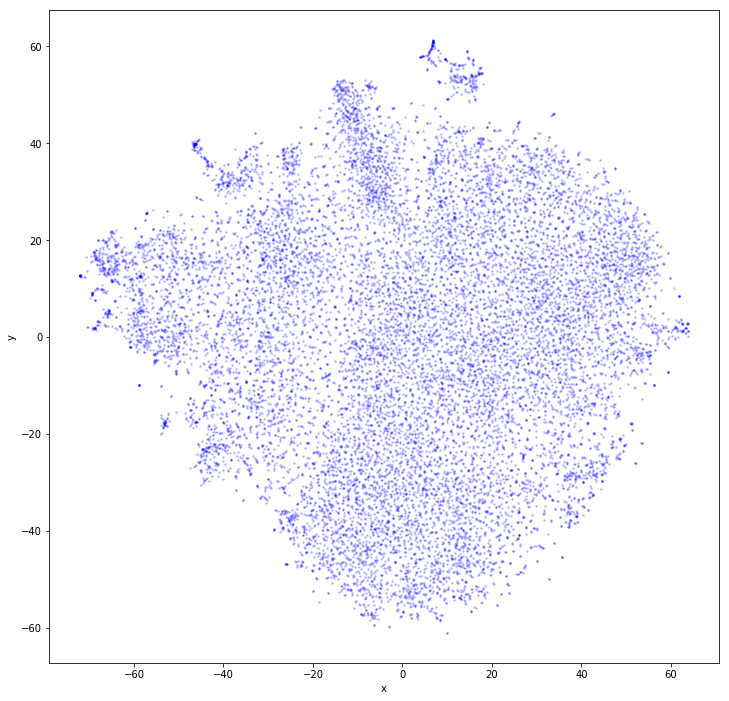

In [93]:
coords_df.plot.scatter('x', 'y', figsize=(12,12), marker='.', s=10, alpha=0.2,c="blue")

In [94]:
output_notebook() # output bokeh plots inline in notebook

Loading BokehJS ...

In [95]:
subset_df = coords_df.sample(n=5000)

In [96]:
p = figure(plot_width=800, plot_height=800)
_ = p.text(x=subset_df.x, y=subset_df.y, text=subset_df.token)

In [97]:
show(p)